In [1]:
import pandas as pd
import numpy as np
import re
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import warnings
#import matplotlib.pyplot as plt
#import matplotlib.cm as cm
#from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
#from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

In [2]:
path = '/gws/nopw/j04/canari/users/bjharvey/era5_psldaymean/'
datasets = []

for year in range(1987, 2023):
    filename = f'psldaymean_{year}.nc'
    with xr.open_dataset(path + filename) as datax:
        datax['longitude'] = (datax['longitude'] + 180) % 360 - 180
        datax = datax.sortby('longitude')
        datax = datax.sel(latitude=slice(80, 30), longitude=slice(-45,45))
        datax = datax.sel(time=datax.time.dt.month.isin([1, 2, 3, 10, 11, 12]))
        datasets.append(datax)

combined_data = xr.concat(datasets, dim='time')
combined_data

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 6561, bnds: 2, latitude: 201, longitude: 361)
Coordinates:
  * time       (time) datetime64[ns] 52kB 1987-01-01T09:00:00 ... 2022-12-31T...
  * longitude  (longitude) float32 1kB -45.0 -44.75 -44.5 ... 44.5 44.75 45.0
  * latitude   (latitude) float32 804B 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 105kB 1987-01-01 ... 2022-12-31T18...
    msl        (time, latitude, longitude) float64 4GB 1.006e+05 ... 1.028e+05
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Aug 21 13:27:29 2023: cdo daymean /home/users/bjharvey/...
    frequency:    day
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [3]:
combined_data.to_netcdf('psl_daymean.nc')

In [3]:
clos_data = pd.read_csv('clos_date_pat.csv')
clos_data['closure_date_true'] = pd.to_datetime(clos_data['closure_date_true'])
clos_data = clos_data[1:]
clos_data

,season,closure_ID,closure_type,Tide,closure_date_true,closure_date_prev,closue_date_next
1,1986-1987,3,Combined,Spring,1987-03-29 09:00:00,1987-03-27 09:00:00,1987-03-31 09:00:00
2,1988-1989,4,Tidal,Spring,1988-12-24 09:00:00,1988-12-22 09:00:00,1988-12-26 09:00:00
3,1989-1990,6,Combined,Spring,1990-02-27 09:00:00,1990-02-25 09:00:00,1990-03-01 09:00:00
4,1989-1990,7,Tidal,Neap,1990-02-28 09:00:00,1990-02-26 09:00:00,1990-03-02 09:00:00
5,1989-1990,8,Tidal,Neap,1990-03-02 09:00:00,1990-02-28 09:00:00,1990-03-04 09:00:00
...,...,...,...,...,...,...,...
94,2021-2022,202,Tidal,Spring,2022-01-04 09:00:00,2022-01-02 09:00:00,2022-01-06 09:00:00
95,2021-2022,203,Tidal,Spring,2022-01-05 09:00:00,2022-01-03 09:00:00,2022-01-07 09:00:00
96,2021-2022,204,Tidal,Spring,2022-01-31 09:00:00,2022-01-29 09:00:00,2022-02-02 09:00:00
97,2021-2022,205,Tidal,Neap,2022-02-04 09:00:00,2022-02-02 09:00:00,2022-02-06 09:00:00


In [4]:
tidal_clos = clos_data[clos_data['closure_type'] == 'Tidal']
com_clos = clos_data[clos_data['closure_type'] == 'Combined']
fluv_clos = clos_data[clos_data['closure_type'] == 'Fluvial']
all_clos = clos_data

In [5]:
tidal_days = combined_data.sel(time=tidal_clos['closure_date_true'].values)
com_days = combined_data.sel(time=com_clos['closure_date_true'].values)
fluv_days = combined_data.sel(time=fluv_clos['closure_date_true'].values)
all_days = combined_data.sel(time=all_clos['closure_date_true'].values)

In [6]:
sel_tidal = tidal_days.mean(dim='time')
lonsi = sel_tidal['longitude']
latsi = sel_tidal['latitude']
msl_tidal = sel_tidal['msl']*0.01

sel_com = com_days.mean(dim='time')
msl_com = sel_com['msl']*0.01

sel_fluv = fluv_days.mean(dim='time')
msl_fluv = sel_fluv['msl']*0.01

sel_data_all = all_days.mean(dim='time')
msl_all = sel_data_all['msl']*0.01

In [7]:
clim_dat = xr.open_dataset('NS_clim_mslp.nc')
monthly_avg = clim_dat.groupby('time.month').mean(dim='time')

In [8]:
# Extract month from the specific dates
months_tidal = tidal_days['time'].dt.month
monthly_avg_for_dates_tidal = monthly_avg.sel(month=months_tidal)
anomaly_tidal = (tidal_days - monthly_avg_for_dates_tidal).mean(dim='time')

months_com = com_days['time'].dt.month
monthly_avg_for_dates_com = monthly_avg.sel(month=months_com)
anomaly_com = (com_days - monthly_avg_for_dates_com).mean(dim='time')

months_fluv = fluv_days['time'].dt.month
monthly_avg_for_dates_fluv = monthly_avg.sel(month=months_fluv)
anomaly_fluv = (fluv_days - monthly_avg_for_dates_fluv).mean(dim='time')

months_all = all_days['time'].dt.month
monthly_avg_for_dates_all = monthly_avg.sel(month=months_all)
anomaly_all = (all_days - monthly_avg_for_dates_all).mean(dim='time')

In [9]:
msl_tidal_anom = anomaly_tidal['msl']*0.01
msl_com_anom = anomaly_com['msl']*0.01
msl_fluv_anom = anomaly_fluv['msl']*0.01
msl_all_anom = anomaly_all['msl']*0.01
msl_all_anom

<xarray.DataArray 'msl' (latitude: 201, longitude: 361)> Size: 580kB
array([[ 2.78401911,  2.7868367 ,  2.79328958, ..., -2.05182224,
        -2.04167697, -2.03294951],
       [ 2.77858057,  2.78478871,  2.79093818, ..., -2.13359507,
        -2.1236016 , -2.11391096],
       [ 2.76657867,  2.77509199,  2.78142815, ..., -2.21753595,
        -2.20741884, -2.19670568],
       ...,
       [ 1.13257782,  1.1228958 ,  1.11247362, ..., -0.08456689,
        -0.08586521, -0.08511222],
       [ 1.10041912,  1.09037605,  1.08068538, ..., -0.06359981,
        -0.07019034, -0.07412251],
       [ 1.06967682,  1.06085706,  1.05319368, ..., -0.04801941,
        -0.05524035, -0.06125664]])
Coordinates:
  * longitude  (longitude) float32 1kB -45.0 -44.75 -44.5 ... 44.5 44.75 45.0
  * latitude   (latitude) float32 804B 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0

In [10]:
msl_tidal_act = tidal_days['msl'].mean(dim='time')*0.01
msl_com_act = com_days['msl'].mean(dim='time')*0.01
msl_fluv_act = fluv_days['msl'].mean(dim='time')*0.01
msl_all_act = all_days['msl'].mean(dim='time')*0.01

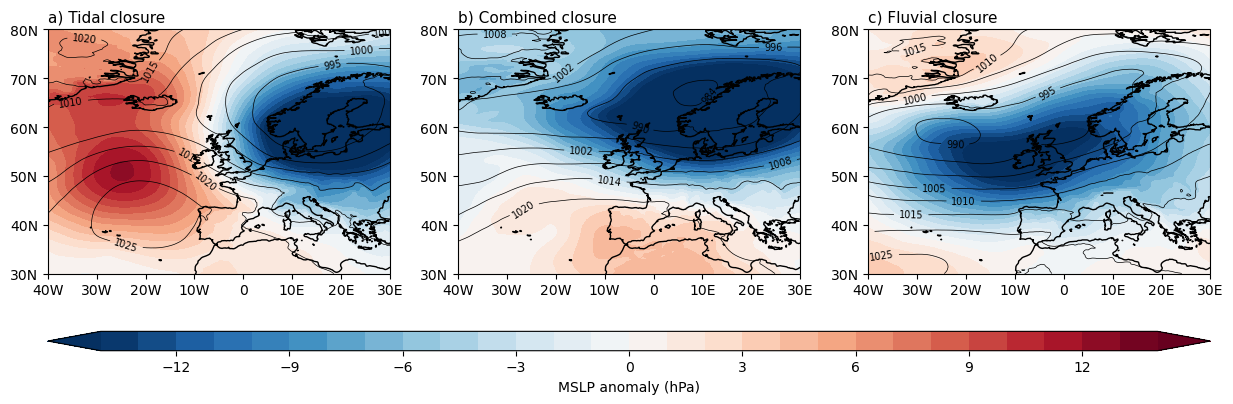

In [16]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
fig, axs = plt.subplots(1, 3, figsize=(15., 5.), subplot_kw={'projection': datacrs})
fig.subplots_adjust(hspace=0.25)

boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

for ax in axs:
    ax.set_extent(boundary, crs=datacrs) 
    ax.set_xticks(lons_tick, crs=datacrs)  
    ax.set_yticks(lats_tick, crs=datacrs)  
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(-14, 15, 1)
contf = axs[0].contourf(lonsi, latsi, msl_tidal_anom, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)
cont_tid = axs[0].contour(lonsi, latsi, msl_tidal_act, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
axs[0].clabel(cont_tid, inline=True, fontsize=7, fmt='%.0f')
axs[0].set_title('a) Tidal closure', weight='normal', loc='left', fontsize=11)

axs[1].contourf(lonsi, latsi, msl_com_anom, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)
cont_com = axs[1].contour(lonsi, latsi, msl_com_act, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
axs[1].clabel(cont_com, inline=True, fontsize=7, fmt='%.0f')
axs[1].set_title('b) Combined closure', weight='normal', loc='left', fontsize=11)

axs[2].contourf(lonsi, latsi, msl_fluv_anom, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)
cont_fluv = axs[2].contour(lonsi, latsi, msl_fluv_act, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
axs[2].clabel(cont_fluv, inline=True, fontsize=7, fmt='%.0f')
axs[2].set_title('c) Fluvial closure', weight='normal', loc='left', fontsize=11)

cb = plt.colorbar(contf, ax=axs, orientation='horizontal', aspect=60)
cb.set_label('MSLP anomaly (hPa)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

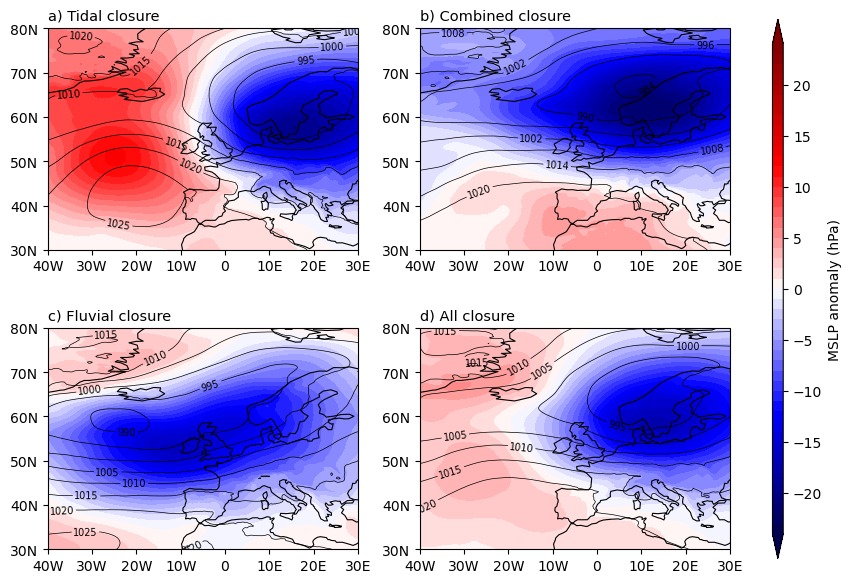

In [19]:
datacrs = ccrs.PlateCarree()

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(11., 7.), subplot_kw={'projection': datacrs})
fig.subplots_adjust(hspace=0.25)

# Define map extent and ticks
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

# Setup each subplot
for ax in axs.flat:
    ax.set_extent(boundary, crs=datacrs)
    ax.set_xticks(lons_tick, crs=datacrs)
    ax.set_yticks(lats_tick, crs=datacrs)
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    #ax.coastlines(linewidth=0.8)
    #ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.coastlines(resolution='110m', linewidth=0.8, color='black')

# Define levels for contour plots
colorvim_levels = np.arange(-24, 25, 1)
cmap_col = plt.cm.seismic

# Plot each data set
contf = axs[0, 0].contourf(lonsi, latsi, msl_tidal_anom, levels=colorvim_levels, cmap=cmap_col, extend='both', transform=datacrs)
cont_tid = axs[0, 0].contour(lonsi, latsi, msl_tidal_act, colors='black', linewidths=0.5, transform=datacrs)
axs[0, 0].clabel(cont_tid, inline=True, fontsize=7, fmt='%.0f')
axs[0, 0].set_title('a) Tidal closure', weight='normal', loc='left', fontsize=10.5)

axs[0, 1].contourf(lonsi, latsi, msl_com_anom, levels=colorvim_levels, cmap=cmap_col, extend='both', transform=datacrs)
cont_com = axs[0, 1].contour(lonsi, latsi, msl_com_act, colors='black', linewidths=0.5, transform=datacrs)
axs[0, 1].clabel(cont_com, inline=True, fontsize=7, fmt='%.0f')
axs[0, 1].set_title('b) Combined closure', weight='normal', loc='left', fontsize=10.5)

axs[1, 0].contourf(lonsi, latsi, msl_fluv_anom, levels=colorvim_levels, cmap=cmap_col, extend='both', transform=datacrs)
cont_fluv = axs[1, 0].contour(lonsi, latsi, msl_fluv_act, colors='black', linewidths=0.5, transform=datacrs)
axs[1, 0].clabel(cont_fluv, inline=True, fontsize=7, fmt='%.0f')
axs[1, 0].set_title('c) Fluvial closure', weight='normal', loc='left', fontsize=10.5)

axs[1, 1].contourf(lonsi, latsi, msl_all_anom, levels=colorvim_levels, cmap=cmap_col, extend='both', transform=datacrs)
cont_all = axs[1, 1].contour(lonsi, latsi, msl_all_act, colors='black', linewidths=0.5, transform=datacrs)
axs[1, 1].clabel(cont_all, inline=True, fontsize=7, fmt='%.0f')
axs[1, 1].set_title('d) All closure', weight='normal', loc='left', fontsize=10.5)

cb = plt.colorbar(contf, ax=axs, orientation='vertical', aspect=50)
cb.set_label('MSLP anomaly (hPa)')

plt.show()


###

In [14]:
all_days = combined_data.sel(time=clos_data['closure_date_true'].values)

<xarray.Dataset> Size: 57MB
Dimensions:    (time: 98, bnds: 2, longitude: 361, latitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 784B 1987-03-29T09:00:00 ... 2022-02-21T...
  * longitude  (longitude) float32 1kB -45.0 -44.75 -44.5 ... 44.5 44.75 45.0
  * latitude   (latitude) float32 804B 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 2kB 1987-03-29 ... 2022-02-21T18:0...
    msl        (time, latitude, longitude) float64 57MB 1.02e+05 ... 1.017e+05
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Aug 21 13:27:29 2023: cdo daymean /home/users/bjharvey/...
    frequency:    day
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [15]:
sel_data_all = all_days.mean(dim='time')
msl_all = sel_data_all['msl']*0.01
months_all = all_days['time'].dt.month
monthly_avg_for_dates_all = monthly_avg.sel(month=months_all)
anom_all = sel_data_all - monthly_avg_for_dates_all
msl_all_act = all_days['msl'].mean(dim='time')*0.01
sel_data_all = anom_all.mean(dim='time')

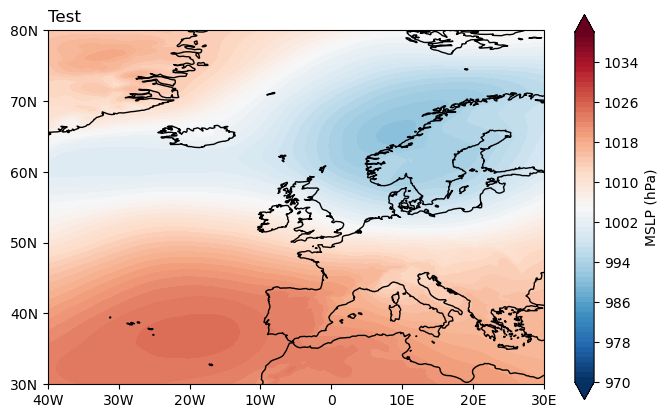

In [25]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(8., 5.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(970, 1041, 1)
contf = ax.contourf(lonsi, latsi, msl, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)

ax.set_title('Test', weight='normal', loc='left')

cb = plt.colorbar(contf, ax=ax, orientation='vertical', aspect=20)
cb.set_label('MSLP (hPa)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'format': 'netcdf',
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'mean_sea_level_pressure',
        'year': [
            '1990', '1991', '1992',
            '1993', '1994', '1995',
            '1996', '1997', '1998',
            '1999', '2000', '2001',
            '2002', '2003', '2004',
            '2005', '2006', '2007',
            '2008', '2009', '2010',
            '2011',
            '2012', '2013', '2014',
            '2015', '2016', '2017',
            '2018', '2019', '2020',

        ],
        'month': ['10', '11', '12', '01', '02', '03'],
        'time': '00:00',
        'area': [
            80, -45, 30,
            45,
        ],
    },
    'NS_clim_mslp.nc')

2024-07-26 12:58:35,386 INFO Welcome to the CDS
2024-07-26 12:58:35,387 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels-monthly-means
2024-07-26 12:58:35,503 INFO Request is queued
2024-07-26 12:58:36,543 INFO Request is running
2024-07-26 13:04:54,727 INFO Request is completed
2024-07-26 13:04:54,728 INFO Downloading https://download-0008-clone.copernicus-climate.eu/cache-compute-0008/cache/data4/adaptor.mars.internal-1721999048.5038328-6970-12-3cc724d1-7ee4-4dc5-8913-5e070790fbbf.nc to NS_clim_mslp.nc (25.6M)
2024-07-26 13:05:05,825 INFO Download rate 2.3M/s   


Result(content_length=26851692,content_type=application/x-netcdf,location=https://download-0008-clone.copernicus-climate.eu/cache-compute-0008/cache/data4/adaptor.mars.internal-1721999048.5038328-6970-12-3cc724d1-7ee4-4dc5-8913-5e070790fbbf.nc)

In [30]:
# Extract month from the specific dates
months = select_days['time'].dt.month
monthly_avg_for_dates = monthly_avg.sel(month=months)
anomaly = select_days - monthly_avg_for_dates

anomaly

<xarray.Dataset> Size: 57MB
Dimensions:    (time: 98, longitude: 361, latitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 784B 1987-03-29T09:00:00 ... 2022-02-21T...
  * longitude  (longitude) float32 1kB -45.0 -44.75 -44.5 ... 44.5 44.75 45.0
  * latitude   (latitude) float32 804B 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
    month      (time) int64 784B 3 12 2 2 3 10 1 1 11 12 ... 3 3 2 10 1 1 1 2 2
Data variables:
    msl        (time, latitude, longitude) float64 57MB 548.3 549.9 ... -15.31

In [54]:
msl_act = select_days['msl'].mean(dim='time')*0.01

In [31]:
sel_data = anomaly.mean(dim='time')
lonsi = sel_data['longitude']
latsi = sel_data['latitude']
msl = sel_data['msl']*0.01

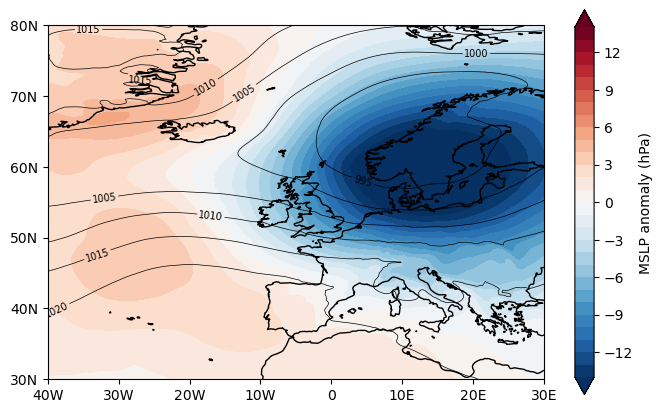

In [56]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(8., 5.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(-14, 15, 1)
contf = ax.contourf(lonsi, latsi, msl, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)
contour_lines = ax.contour(lonsi, latsi, msl_act, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
ax.clabel(contour_lines, inline=True, fontsize=7, fmt='%.0f')

ax.set_title('', weight='normal', loc='left')

cb = plt.colorbar(contf, ax=ax, orientation='vertical', aspect=20)
cb.set_label('MSLP anomaly (hPa)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()